https://github.com/jackson-stokes/DSCI235_Final_Project

# DSCI 235 Final Project: Portuguese Wine Quality

**Topic:** Analyzing the properties of red and white variants of the Portuguese Vinho Verde wine to determine which traits drive higher quality ratings.
**Data Source:** UC Irvine Machine Learning Repository - Wine Quality Dataset
**Addressing:**
1. Do red and white wines have statistically different average quality scores?
2. Which property has the strongest correlation with high quality ratings?
3. How does the distribution of alcohol content differ between high and low rated wines?


**Reasoning:** I wanted to choose this topic as I am traveling to Portugal in May of this year where I will be doing several wine tours across the country, primarily in the Douro Valley of northern Portugal in hopes to learn more about a subject that I am very passionate about. This project will give me more questions to ask my tour guides, and it will give me further insight into why some wines are rated higher than others even when they originate from the same region or even the same vinyard. 

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

First, we import the libraries.
The data is formated using semicolons instead of commas, so we must explicitly account for this to ensure proper parsing of the data into columns.

In [37]:
url_red = "https://raw.githubusercontent.com/jackson-stokes/DSCI235_Final_Project/refs/heads/main/winequality-red.csv"
url_white = "https://raw.githubusercontent.com/jackson-stokes/DSCI235_Final_Project/refs/heads/main/winequality-white.csv"

df_red = pd.read_csv(url_red, sep=';')
df_white = pd.read_csv(url_white, sep=';')

To begin comparing the 2 datasets, we need to combine them into a single dataframe.

Before concatenating, we will add a new category that assigns the type of wine in the row. 

In [38]:
df_red['wine_type'] = 'red'
df_white['wine_type'] = 'white'

wine_df = pd.concat([df_red, df_white], ignore_index=True)
wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


We will add another category to put wines in a box of either Low, Medium, or High quality rather than numerical values to allow for easier accessibility and readability of the data. 

To do this, we can just use the Numpy where() function with 7 and above being High, 4 and below being Low, and leaving the middle gap for Medium.

In [39]:
wine_df['rating_category'] = np.where(wine_df['quality'] >= 7, 'High', 
                                    np.where(wine_df['quality'] <= 4, 'Low', 
                                    'Medium'))

print(f"Number of rows in red wine dataset: {df_red.shape[0]}")
print(f"Number of rows in white wine dataset: {df_white.shape[0]}")
print(f"Number of rows in new dataset with categorical rating: {wine_df.shape[0]}")
wine_df.head(10)

Number of rows in red wine dataset: 1599
Number of rows in white wine dataset: 4898
Number of rows in new dataset with categorical rating: 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,rating_category
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,Medium
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red,Medium
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red,Medium
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red,Medium
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red,Medium
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red,Medium
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red,Medium
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red,High
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red,High
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red,Medium


Now that the data is merged, we can run a check to verify the integrity of the dataset.

We will check for null values that will skew our analyses as well as confirm that the data types are usable for numerical analysis.

In [40]:
missing_values = wine_df.isnull().sum()
print("Missing values:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("Result: Dataset has no missing values.")
else:
    print("Result: Dataset has missing values.")
    
wine_df.describe().round(2)

Missing values:
Series([], dtype: int64)
Result: Dataset has no missing values.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00,6497.00
mean,7.22,0.34,0.32,5.44,0.06,30.53,115.74,0.99,3.22,0.53,10.49,5.82
std,1.30,0.16,0.15,4.76,0.04,17.75,56.52,0.00,0.16,0.15,1.19,0.87
min,3.80,0.08,0.00,0.60,0.01,1.00,6.00,0.99,2.72,0.22,8.00,3.00
25%,6.40,0.23,0.25,1.80,0.04,17.00,77.00,0.99,3.11,0.43,9.50,5.00
50%,7.00,0.29,0.31,3.00,0.05,29.00,118.00,0.99,3.21,0.51,10.30,6.00
75%,7.70,0.40,0.39,8.10,0.06,41.00,156.00,1.00,3.32,0.60,11.30,6.00
max,15.90,1.58,1.66,65.80,0.61,289.00,440.00,1.04,4.01,2.00,14.90,9.00


Using Pandas boxplot and formatting with Matplotlib, we will look at the distribution of alcohol content across the varying quality ratings. 

We are using a boxplot because it will display the median, spread, and outliers of the alcohol variable against the quality score. 

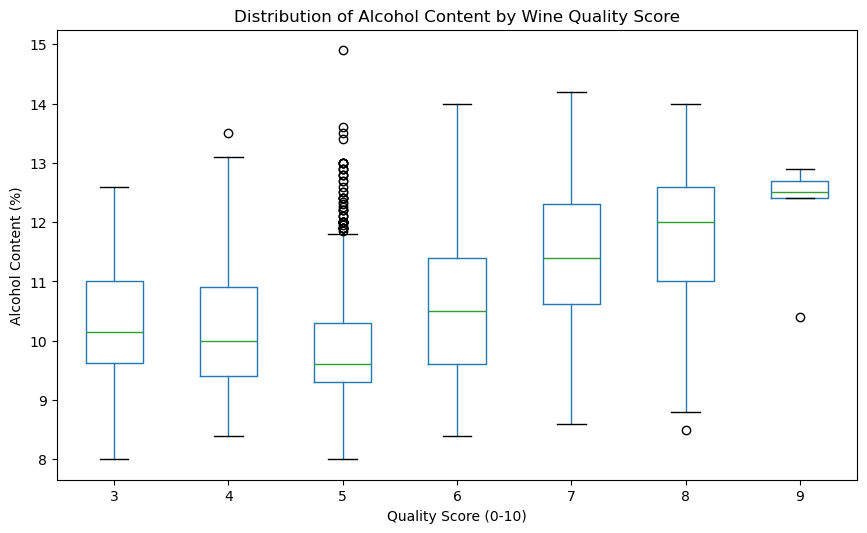

In [41]:
ax = wine_df.boxplot(column='alcohol', by='quality', grid=False, figsize=(10,6), return_type='axes')

plt.title('Distribution of Alcohol Content by Wine Quality Score')
plt.suptitle('')
plt.xlabel('Quality Score (0-10)')
plt.ylabel('Alcohol Content (%)')
plt.show()

To now answer our main question, is there a significant difference in baseline quality between red and white wines?

To visualize this, we will group the merged dataframe by our 'wine_type' column and calculate the mean of the 'quality' column.

In [42]:
type_quality = wine_df.groupby('wine_type')['quality'].mean()
type_quality

wine_type
red      5.636023
white    5.877909
Name: quality, dtype: float64

Now we can plot this data as a bar chart representing the average quality by wine type.

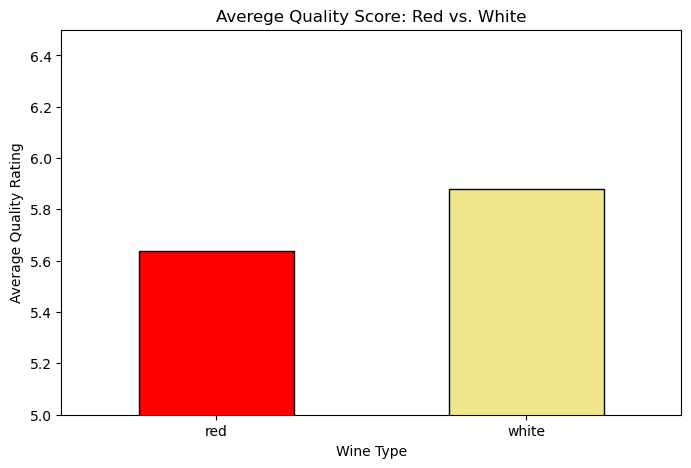

In [43]:
plt.figure(figsize=(8,5))
type_quality.plot(kind='bar', color=['red', 'khaki'], edgecolor='black')

plt.title('Averege Quality Score: Red vs. White')
plt.xlabel('Wine Type')
plt.ylabel('Average Quality Rating')
plt.xticks(rotation=0)
plt.ylim(5, 6.5)
plt.show()

To more adequately address our question, we must look at the distribution shape of alcohol content between the best and worst wines.

To do this, we will filter our dataframe using the 'rating_category' column that we created, and plot the overlapping histograms.

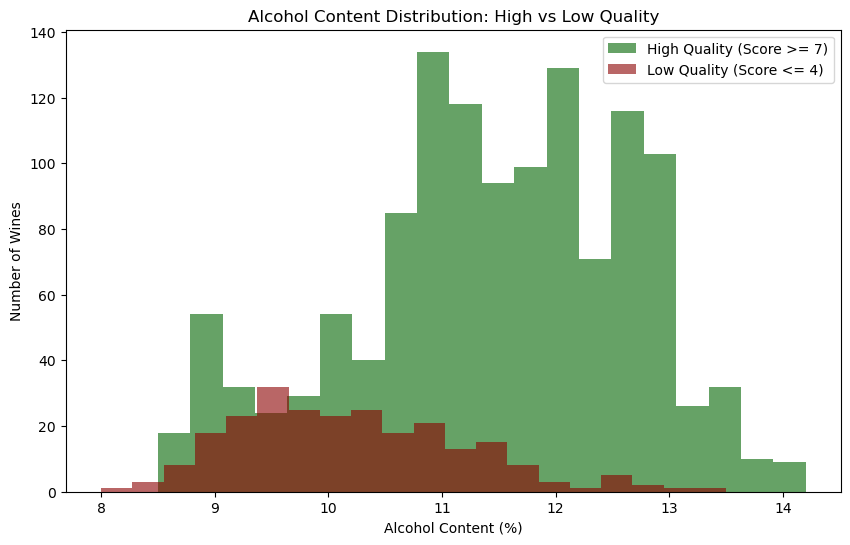

In [44]:
plt.figure(figsize=(10,6))

high_quality = wine_df[wine_df['rating_category'] == 'High']['alcohol']
low_quality = wine_df[wine_df['rating_category'] == 'Low']['alcohol']

high_quality.plot(kind='hist', alpha=0.6, color='darkgreen', bins=20, label='High Quality (Score >= 7)')
low_quality.plot(kind='hist', alpha=0.6, color='darkred', bins=20, label='Low Quality (Score <= 4)')

plt.title('Alcohol Content Distribution: High vs Low Quality')
plt.xlabel('Alcohol Content (%)')
plt.ylabel('Number of Wines')
plt.legend()
plt.show()

## Conclusion
1. The visualizations clearly demonstrate a positive trend between alcohol content and quality. The boxplot shows that premium wines consistently have higher median alcohol percentages, and the overlapping histogram shows that the distrubution of high quality wines is heavily shifted towards higher alcohol contents compared to wines of lower quality. 
2. By merging the datasets and categorizing the quality scores, we found that white wines have only a marginally higher average quality score than red wines, though both average around 5.6 and 5.9.
3. Through assigning type labels and checking for missing values prior to concatentation, we ensured a clean, non-trivial merge that maintained the integrity of each individual subset while performing a unified analysis.

Jackson Stokes